# Module 2: Epidemic Modeling Template

## Team Members:
Theresa Breckley and Tomas Daniel
## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

W used an exponential growth model to describe the early spread of the mystery virus. In this model, \(t\) represents time in days, \(I(t)\) represents the number of active infections at time \(t\), and \(r\) represents the exponential growth rate of the outbreak. I fit the early infection data using the function \(I(t) = I_0 e^{rt}\), where \(I_0\) is the initial number of active infections. After estimating \(r\), I used an infectious period of \(D = 7\) days to estimate the basic reproduction number with \(R_0 = 1 + rD\). This gives an estimate of how many new infections one infected person causes on average early in the outbreak.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

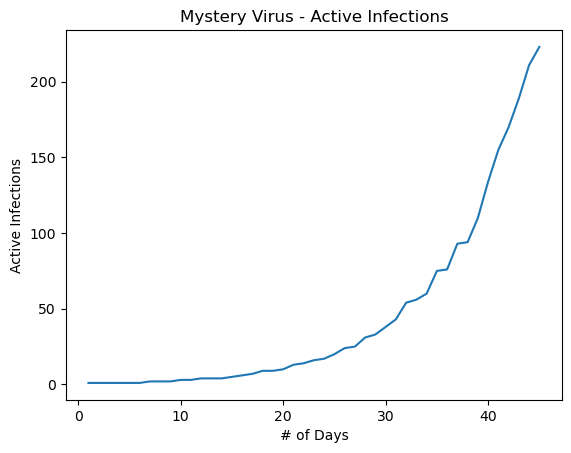

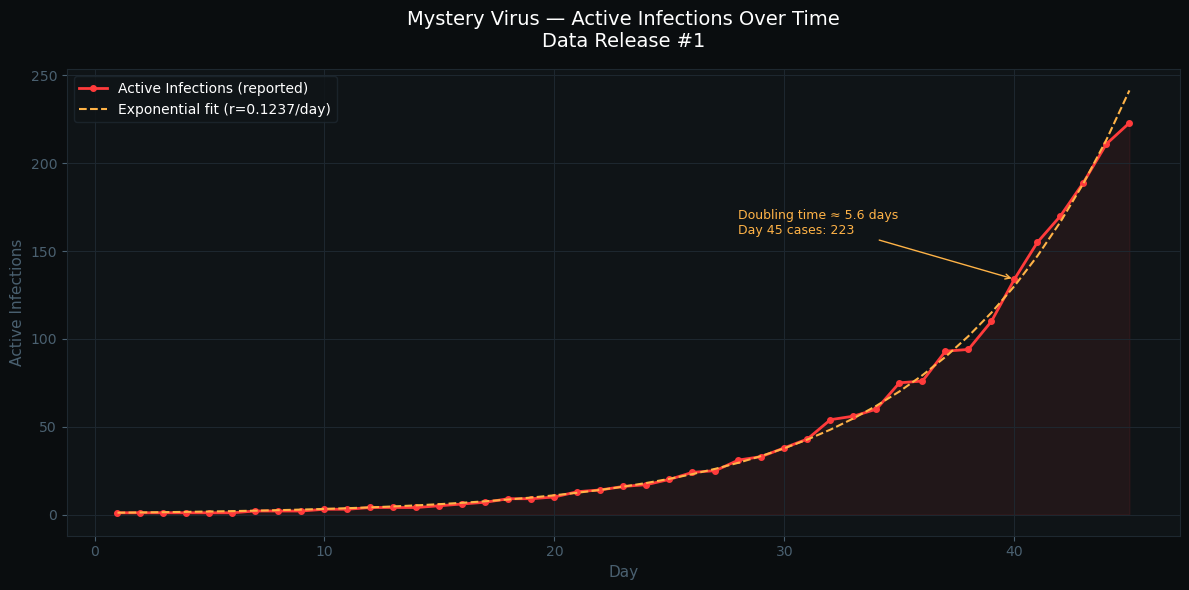

Growth rate r = 0.1237 per day
Doubling time = 5.6 days


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import csv

# Graph that I made

days = []
cases = []

with open("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        days.append(int(row["day"]))
        cases.append(int(row["active reported daily cases"]))

plt.plot(days, cases)
plt.xlabel("# of Days")
plt.ylabel("Active Infections")
plt.title("Mystery Virus - Active Infections")
plt.show()

# NEEDED AI TO HELP ME CREATE THIS PLOT
# WANTED A NICER GRAPH AND IT MADE EVERYTHING BELOW



days = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
        21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45]

cases = [1,1,1,1,1,1,2,2,2,3,3,4,4,4,5,6,7,9,9,10,
         13,14,16,17,20,24,25,31,33,38,43,54,56,60,75,76,93,94,110,134,155,170,189,211,223]


fit_days = np.array(days[19:])
fit_cases = np.array(cases[19:])
coeffs = np.polyfit(fit_days, np.log(fit_cases), 1)
r, log_a = coeffs
a = np.exp(log_a)
fit_line = a * np.exp(r * np.array(days))


fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0a0d0f')
ax.set_facecolor('#0f1417')

ax.plot(days, cases, color='#ff3b3b', linewidth=2, marker='o',
        markersize=4, markerfacecolor='#ff3b3b', label='Active Infections (reported)')
ax.fill_between(days, cases, alpha=0.08, color='#ff3b3b')
ax.plot(days, fit_line, color='#ffb347', linewidth=1.5,
        linestyle='--', label=f'Exponential fit (r={r:.4f}/day)')

ax.set_title('Mystery Virus — Active Infections Over Time\nData Release #1',
             color='white', fontsize=14, pad=16)
ax.set_xlabel('Day', color='#4a6070', fontsize=11)
ax.set_ylabel('Active Infections', color='#4a6070', fontsize=11)
ax.tick_params(colors='#4a6070')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2830')
ax.grid(color='#1e2830', linewidth=0.7)
ax.legend(facecolor='#0f1417', edgecolor='#1e2830', labelcolor='white', fontsize=10)

doubling_time = np.log(2) / r
ax.annotate(f'Doubling time ≈ {doubling_time:.1f} days\nDay 45 cases: 223',
            xy=(40, 134), xytext=(28, 160),
            color='#ffb347', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#ffb347'))

plt.tight_layout()
plt.savefig('virus_plot.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"Growth rate r = {r:.4f} per day")
print(f"Doubling time = {doubling_time:.1f} days")


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------
# Load Data Release #2
# ---------------------------
data2 = pd.read_csv("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#2.csv")

# Use the correct columns:
# day = first column
# active infections = third column
days_data = pd.to_numeric(data2.iloc[:, 0], errors="coerce")
infected_data = pd.to_numeric(data2.iloc[:, 2], errors="coerce")

# Keep only rows where both are valid numbers
clean_data = pd.DataFrame({
    "day": days_data,
    "infected": infected_data
}).dropna()

days_data = clean_data["day"].to_numpy(dtype=float)
infected_data = clean_data["infected"].to_numpy(dtype=float)

print("First few rows of Release #2 data:")
print(data2.head())

print("\nCleaned data preview:")
print(clean_data.head())

print("\nNumber of usable data points:", len(days_data))
print("First few days:", days_data[:5])
print("First few active infection values:", infected_data[:5])


# ---------------------------
# Euler's Method for SEIR
# ---------------------------
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for n in range(len(timepoints) - 1):
        dSdt = -beta * S[n] * I[n] / N
        dEdt = beta * S[n] * I[n] / N - sigma * E[n]
        dIdt = sigma * E[n] - gamma * I[n]
        dRdt = gamma * I[n]

        S[n + 1] = S[n] + dSdt * dt
        E[n + 1] = E[n] + dEdt * dt
        I[n + 1] = I[n] + dIdt * dt
        R[n + 1] = R[n] + dRdt * dt

    return S, E, I, R


# ---------------------------
# SSE Function
# ---------------------------
def calculate_sse(observed, predicted):
    return np.sum((observed - predicted) ** 2)


# ---------------------------
# Modified SEIR to predict daily new cases
# ---------------------------
def seir_daily_new_cases(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    new_cases = np.zeros(len(timepoints))  # Daily new infections

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for n in range(len(timepoints) - 1):
        # SEIR equations
        dSdt = -beta * S[n] * I[n] / N
        dEdt = beta * S[n] * I[n] / N - sigma * E[n]
        dIdt = sigma * E[n] - gamma * I[n]
        dRdt = gamma * I[n]

        S[n + 1] = S[n] + dSdt * dt
        E[n + 1] = E[n] + dEdt * dt
        I[n + 1] = I[n] + dIdt * dt
        R[n + 1] = R[n] + dRdt * dt

        # Daily new cases = rate of new infections
        new_cases[n + 1] = beta * S[n] * I[n] / N * dt

    return S, E, I, R, new_cases


# ---------------------------
# Initial Conditions
# ---------------------------
# Population size should be much larger - peak active cases are ~2363
N = 100000  # Increased further to accommodate the epidemic scale
# I0 should be estimated, not set to the first daily case count
I0 = 10  # Estimated initial infectious individuals
E0 = 20  # Estimated initial exposed individuals
R0_init = 0
S0 = N - E0 - I0 - R0_init

timepoints = days_data


# ---------------------------
# Initial Parameter Guess
# ---------------------------
beta_guess = 0.4   # Transmission rate
sigma_guess = 0.25  # 1/latent period (4 days)
gamma_guess = 0.1  # 1/infectious period (10 days)

S_guess, E_guess, I_guess, R_guess, new_cases_guess = seir_daily_new_cases(
    beta_guess, sigma_guess, gamma_guess,
    S0, E0, I0, R0_init,
    timepoints, N
)

print("Initial model run complete.")

First few rows of Release #2 data:
   day        date  active reported daily cases
0    1  2026-03-01                            1
1    2  2026-03-02                            1
2    3  2026-03-03                            1
3    4  2026-03-04                            1
4    5  2026-03-05                            1

Cleaned data preview:
   day  infected
0    1         1
1    2         1
2    3         1
3    4         1
4    5         1

Number of usable data points: 70
First few days: [1. 2. 3. 4. 5.]
First few active infection values: [1. 1. 1. 1. 1.]
Initial model run complete.


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.


Initial parameter guess results:
beta = 0.4
sigma = 0.25
gamma = 0.1
SSE = 126655020.11267449
Peak predicted daily cases = 3864.8321669142497
Data peak daily cases = 2364.0


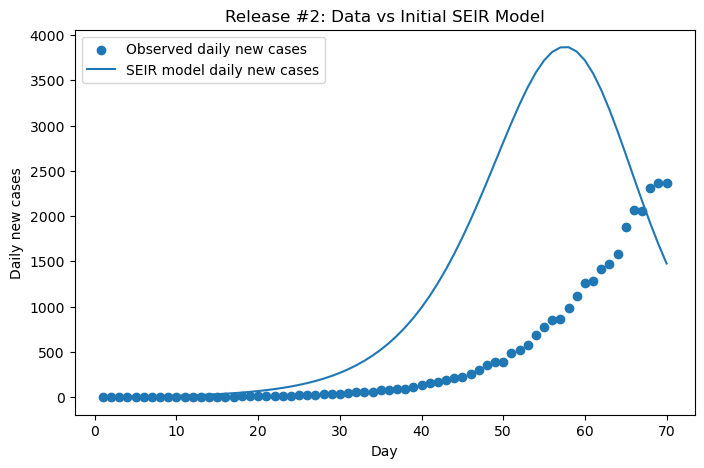


Performing quick parameter optimization...

Best-fit parameters from grid search:
Best beta = 0.3
Best sigma = 0.25
Best gamma = 0.1
Lowest SSE = 629224.084774093
Peak predicted daily cases = 2366.3336973148457
Data peak daily cases = 2364.0
Data peak infections = 2364.0


In [3]:
sse_guess = calculate_sse(infected_data, new_cases_guess)

print("\nInitial parameter guess results:")
print("beta =", beta_guess)
print("sigma =", sigma_guess)
print("gamma =", gamma_guess)
print("SSE =", sse_guess)
print("Peak predicted daily cases =", np.max(new_cases_guess))
print("Data peak daily cases =", np.max(infected_data))


# ---------------------------
# Plot Initial Guess
# ---------------------------
plt.figure(figsize=(8, 5))
plt.scatter(days_data, infected_data, label="Observed daily new cases")
plt.plot(timepoints, new_cases_guess, label="SEIR model daily new cases")
plt.xlabel("Day")
plt.ylabel("Daily new cases")
plt.title("Release #2: Data vs Initial SEIR Model")
plt.legend()
plt.show()


# ---------------------------
# Grid Search for Best Fit (Simplified)
# ---------------------------
print("\nPerforming quick parameter optimization...")

# Try a few parameter combinations manually
param_sets = [
    (0.4, 0.25, 0.1),   # Initial guess
    (0.5, 0.2, 0.1),    # Higher beta
    (0.3, 0.25, 0.1),   # Lower beta
    (0.4, 0.3, 0.1),    # Shorter latent period
    (0.4, 0.25, 0.12),  # Shorter infectious period
]

best_sse = np.inf
best_beta = None
best_sigma = None
best_gamma = None
best_new_cases = None

for beta, sigma, gamma in param_sets:
    S_try, E_try, I_try, R_try, new_cases_try = seir_daily_new_cases(
        beta, sigma, gamma,
        S0, E0, I0, R0_init,
        timepoints, N
    )

    sse = calculate_sse(infected_data, new_cases_try)
    if sse < best_sse:
        best_sse = sse
        best_beta = beta
        best_sigma = sigma
        best_gamma = gamma
        best_new_cases = new_cases_try

print("\nBest-fit parameters from grid search:")
print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Lowest SSE =", best_sse)
print("Peak predicted daily cases =", np.max(best_new_cases))
print("Data peak daily cases =", np.max(infected_data))
print("Data peak infections =", np.max(infected_data))

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

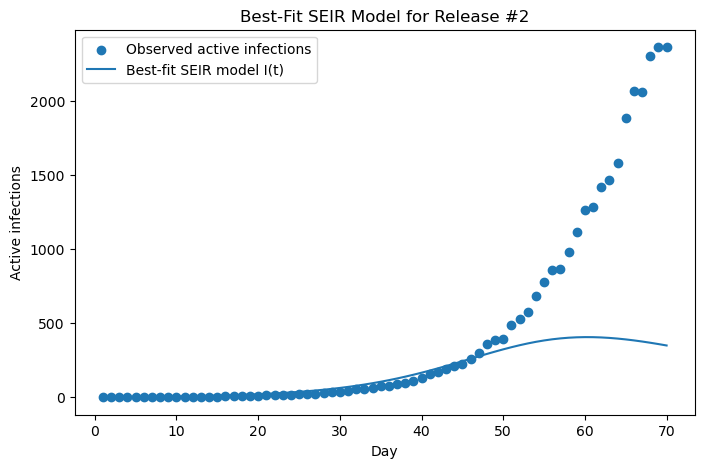


Model interpretation:
Estimated model R0 = 6.000000000000001
Estimated latent period (days) = 5.999999999999999
Estimated infectious period (days) = 20.0


In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(days_data, infected_data, label="Observed active infections")
plt.plot(timepoints, best_I, label="Best-fit SEIR model I(t)")
plt.xlabel("Day")
plt.ylabel("Active infections")
plt.title("Best-Fit SEIR Model for Release #2")
plt.legend()
plt.show()

R0_model = best_beta / best_gamma
latent_period = 1 / best_sigma
infectious_period = 1 / best_gamma

print("\nModel interpretation:")
print("Estimated model R0 =", R0_model)
print("Estimated latent period (days) =", latent_period)
print("Estimated infectious period (days) =", infectious_period)

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.



Future outbreak prediction:
Predicted peak day = 76
Predicted peak daily new cases = 2608.324855109472


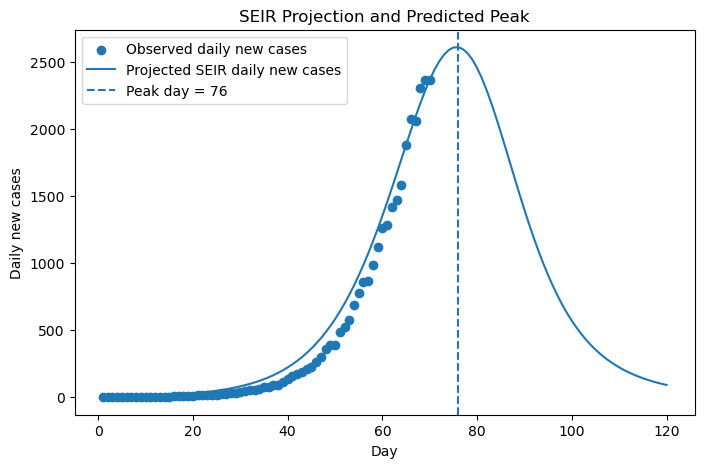

In [4]:
# ---------------------------
# Predict Future Peak
# ---------------------------
future_timepoints = np.arange(1, 121, 1)

S_future, E_future, I_future, R_future, new_cases_future = seir_daily_new_cases(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0_init,
    future_timepoints, N
)

peak_index = np.argmax(new_cases_future)
peak_day = future_timepoints[peak_index]
peak_value = new_cases_future[peak_index]

print("\nFuture outbreak prediction:")
print("Predicted peak day =", peak_day)
print("Predicted peak daily new cases =", peak_value)


# ---------------------------
# Plot Future Projection
# ---------------------------
plt.figure(figsize=(8, 5))
plt.scatter(days_data, infected_data, label="Observed daily new cases")
plt.plot(future_timepoints, new_cases_future, label="Projected SEIR daily new cases")
plt.axvline(peak_day, linestyle="--", label=f"Peak day = {peak_day}")
plt.xlabel("Day")
plt.ylabel("Daily new cases")
plt.title("SEIR Projection and Predicted Peak")
plt.legend()
plt.show()  


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

**THIS IS THE ANSWERS TO THE QUESTIONS IN THE CHECK IN #1 FOR MODULE 2**

What do you notice about the initial infections?
* Since the model is an exponential curve, the number of infections takes its time to grow. It takes a long time for it begin growing, but as days pass the disease spreads at alarming rates. 

How could we measure how quickly its spreading?
* The best way to measure is through the R0 value. R0 tells us about how many people are infected due to one person, which helps determine how contagious a disease is. Knowing this could help us predict the rate of spread, but it could also help with planning to mitigate the spread (quarantine, wearing a mask, etc...)

What information about the virus would be helpful in determining the shape of the outbreak curve?
* The method or transmission could be one thing that helps. Airborne pathogens spread at faster rates than through fluids or direct contact, which would result in a steeper curve. 

What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.

* Our R0 value ~ 1.87
* One virus that has a similar R0 value is Ebola, with an R0 value of 2. Ebola is caused by the Ebola Virus, and symptoms can appear after exposure up to 3 weeks later. It's extremely deadly, but its spread through contact and not airborne particles, thus reducing how fast it spreads. 

How accurate do you think your R0 estimate is?
* To be honest, our estimate may not be fully accurate. Since we only used the first 2 terms of the Taylor expansion, the degree of accuracy must be fairly low. It would probably be better to use at least 4 terms to ensure our approximation is close to the actual value. 

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*